# Building Structured RDDL Policies with JaxPlan

This advanced notebook illustrates how a structured RDDL-described policy can be designed and optimized with JaxPlan. 

In the previous notebook, we used JAX objects to define a custom policy. This can be disadvantageous in applications where we want to test and compare a number of different policy structures easily, or if we wanted to generate/learn the policy structures programmatically. A simpler alternative is to leverage the RDDL language to describe the policy itself (i.e. how states map to actions, what the trainable parameters are, etc.). 

Another advantage of defining a RDDL policy is that the JAX compiler will automatically perform the differentiable relaxations, allowing gradients with respect to the trainable parameters to be computed even for discrete policy structures.

First install and import the required packages:

In [1]:
%pip install --quiet --upgrade pip
%pip install --quiet pyRDDLGym rddlrepository pyRDDLGym-jax

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import the required packages:

In [1]:
import os
from IPython.display import Image
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from rddlrepository.core.manager import RDDLRepoManager
import pyRDDLGym
from pyRDDLGym.core.visualizer.movie import MovieGenerator
from pyRDDLGym_jax.core.planner import JaxBackpropPlanner, JaxOfflineController, load_config_from_string

For this example, we will define a policy symbolically in RDDL that compares the (weighted) average ball y-coordinate to the current paddle y-coordinate, and acting appropriately:

`move = if ([sum_{?b : ball} W(?b) * ball-y(?b)] + Wp * paddle-y) then 1 else -1`

Here, ``W, Wp`` are the trainable parameters of the policy which we will learn. Let's load the Pong domain and instance from the repository, and append the policy code the domain:

In [2]:
# load domain and instance from RDDL repository
info = RDDLRepoManager().get_problem('Pong_arcade')
with open(info.get_domain()) as file:
    domain_text = file.read()
with open(info.get_instance('0')) as file:
    instance_text = file.read()

# append the policy code
domain_text += """
policy simple_policy {
    pvariables {
        W(ball) : { param-fluent, real, default = 0.0 };    // trainable parameters
        Wp      : { param-fluent, real, default = 0.0 };    // trainable parameters
    };
    cpfs {
        move = if ([sum_{?b : ball} W(?b) * ball-y(?b)] + Wp * paddle-y) then 1 else -1;
    };
}
"""

To be able to load this environment in future executions, we register it with the repository:

In [4]:
manager = RDDLRepoManager(rebuild=True)
manager.register_domain("Pongpolicy", "arcade", domain_text, desc="a visual pong domain with a RDDL policy", viz=None)
manager.get_problem("Pongpolicy_arcade").register_instance("0", instance_text)
_ = RDDLRepoManager(rebuild=True)

Domain <Pongpolicy> was successfully registered in rddlrepository with context <arcade>.
Instance <0> was successfully registered in rddlrepository for domain <Pongpolicy_arcade>.


Let's now load this environment and copy the visualizer from the original Pong domain:

In [5]:
env = pyRDDLGym.make('Pongpolicy_arcade', '0', vectorized=True)
viz = pyRDDLGym.make('Pong_arcade', '0')._visualizer.__class__
env.set_visualizer(viz)

To run JaxPlan, we use the ``JaxRDDLPolicy`` class instead of straight-line plan or DRP, which will automatically build the computation graph from the RDDL policy description we just created:

In [6]:
config = """
[Compiler]
[Planner]
method='JaxRDDLPolicy'
optimizer_kwargs={'learning_rate': 0.0005}
[Optimize]
key=42
train_seconds=30
"""
planner_args, _, train_args = load_config_from_string(config)
planner = JaxBackpropPlanner(rddl=env.model, **planner_args)
agent = JaxOfflineController(planner, print_summary=False, **train_args)
agent.evaluate(env, episodes=1)

[INFO] Compiler will cast pvars {'contact', 'move'} to float.
[INFO] Compiler will cast CPFs {'contact'} to float.
[INFO] Compiler will cast policy cpfs {'move'} to float.
[INFO] Bounds of action-fluent <move> set to (array(-1., dtype=float32), array(1., dtype=float32)).
[INFO] JaxPlan will use the policy defined in the policy block: param-fluents {'W', 'Wp'} will be optimized.


 663 it |    -214.13498 train |   -1495.50159 test |    -206.46114 [138 it] pgpe |    -183.60464 best | 5 status: 100%|██████████| 00:29 , 22.13it/s


{'mean': np.float64(-298.5000000000002),
 'median': np.float64(-298.5000000000002),
 'min': np.float64(-298.5000000000002),
 'max': np.float64(-298.5000000000002),
 'std': np.float64(0.0)}

Let's visualize the policy behavior:

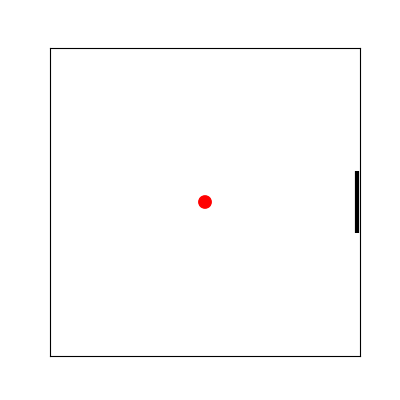

In [7]:
if not os.path.exists('frames'):
    os.makedirs('frames')
recorder = MovieGenerator("frames", "pong_rddl", max_frames=env.horizon)
env.set_visualizer(viz=None, movie_gen=recorder)
agent.evaluate(env, episodes=1, render=True)
env.close()
Image(filename='frames/pong_rddl_0.gif') 

Finally, let's inspect the trained parameters:

In [8]:
print(agent.params)

{'W': Array([6.0664406], dtype=float32), 'Wp': Array(-6.2368317, dtype=float32)}
